# 📊 Estudo de Caso: Desempenho de Alunos

Você foi contratado como cientista de dados para analisar o desempenho de uma turma.
Seu objetivo é gerar insights para melhorar o ensino.

Utilizando o material e as métricas apresentadas na aula de hoje, apresente seus _insigths_ para o _dataset_ apresentado:

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../dataset_estudo_estatistica.csv')
df.head()

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota
0,7,39,10,167,1,Manhã,Java,75.596400
1,4,39,9,183,1,Manhã,Java,0.000000
2,8,37,6,166,0,Manhã,C,66.178579
3,5,9,11,109,0,Noite,Python,35.059806
4,7,110,8,166,1,Noite,C,57.371902


## Exercício 1
Descreva e analise algo relevante nos dados.

In [62]:
df.describe()
#Sem tratamento dos dados e de outliers, podemos ter um panorama inicial do dataset

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,nota
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,5.362500,59.950000,5.275000,128.412500,0.512500,44.635219
std,2.615648,33.920197,3.676731,48.334985,0.502997,27.985507
min,1.000000,5.000000,0.000000,21.000000,0.000000,0.000000
25%,3.000000,32.750000,2.000000,99.250000,0.000000,21.701485
50%,5.000000,53.500000,5.000000,138.500000,1.000000,47.506161
75%,8.000000,92.500000,8.000000,167.000000,1.000000,64.595390
max,9.000000,119.000000,11.000000,197.000000,1.000000,100.000000


## Exercício 2
Descreva e analise algo relevante nos dados.

In [63]:
df.isna().sum()

horas_estudo          0
acessos_plataforma    0
faltas                0
tempo_resolucao       0
bolsa_estagio         0
turno                 0
linguagem             0
nota                  0
dtype: int64

Verificamos que não existem dados faltantes

## Exercício 3
Descreva e analise algo relevante nos dados.

In [64]:
def find_outliers(frame, column):
    q1 = frame[column].quantile(0.25)
    q3 = frame[column].quantile(0.75)
    iqr = q3 - q1
    inferior_limit = q1 - 1.5 * iqr
    superior_limit = q3 + 1.5 * iqr
    outliers = frame[(frame[column] < inferior_limit) | (frame[column] > superior_limit)]
    return outliers

find_outliers(df, "horas_estudo")
find_outliers(df, "acessos_plataforma")
find_outliers(df, "faltas")
find_outliers(df, "tempo_resolucao")
find_outliers(df, "nota")

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota


Nota-se que os dados são relativamente consistentes, uma vez que não foram encontrados outliers em nenhuma das colunas quantitativas.

## Exercício 4
Descreva e analise algo relevante nos dados.

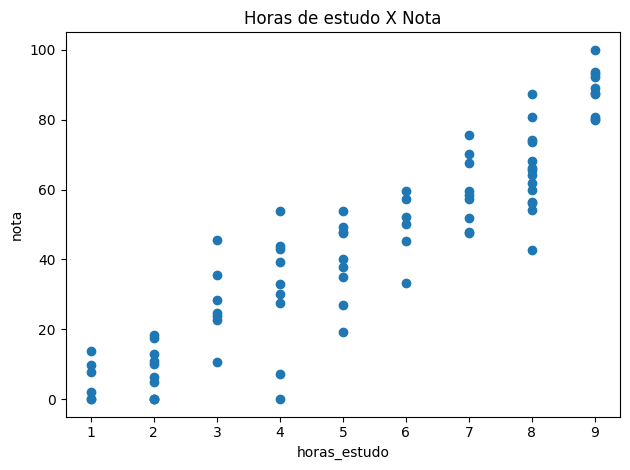

In [65]:
plt.figure()
plt.scatter(df["horas_estudo"], df["nota"])
plt.title("Horas de estudo X Nota")
plt.ylabel("nota")
plt.xlabel("horas_estudo")
plt.tight_layout()
plt.show()

Observa-se uma correlação positiva entre horas de estudo e nota na matéria

## Exercício 5
Descreva e analise algo relevante nos dados.

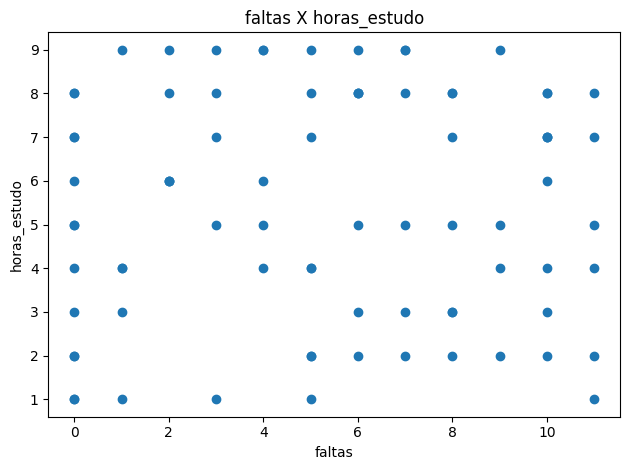

In [66]:
def correlate(frame, columnX, columnY):
    plt.figure()
    plt.scatter(frame[columnX], frame[columnY])
    plt.title(f"{columnX} X {columnY}")
    plt.ylabel(columnY)
    plt.xlabel(columnX)
    plt.tight_layout()
    plt.show()
    
correlate(df, "faltas", "horas_estudo")

Observa-se que não há correlação entre faltas e horas de estudo. Agora, veremos se os alunos que mais faltaram tiveram notas mais baixas.

## Exercício 6
Descreva e analise algo relevante nos dados.

Text(0, 0.5, 'Média das Notas')

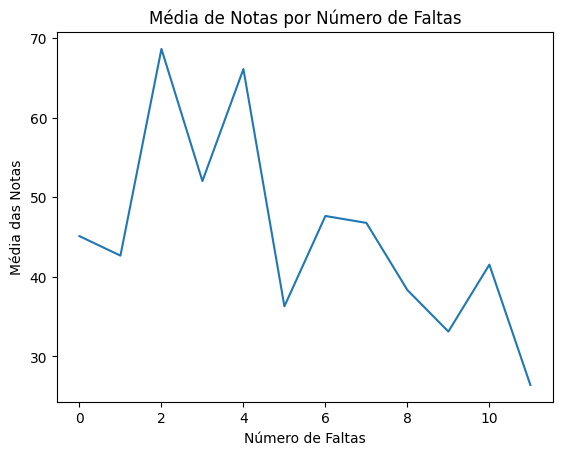

In [67]:
media_vs_faltas = df.groupby('faltas')['nota'].mean().sort_index()
media_vs_faltas.plot(kind='line')
plt.title('Média de Notas por Número de Faltas')
plt.xlabel('Número de Faltas')
plt.ylabel('Média das Notas')

Aqui, observa-se que alunos que tiveram muitas faltas, principalmente de 8 faltas acima, obtiveram notas mais baixas.

## Exercício 7
Descreva e analise algo relevante nos dados.

Averiguando se a linguagem utilizada pelos alunos teve impagto significante em suas notas:

Text(0, 0.5, 'Média das Notas')

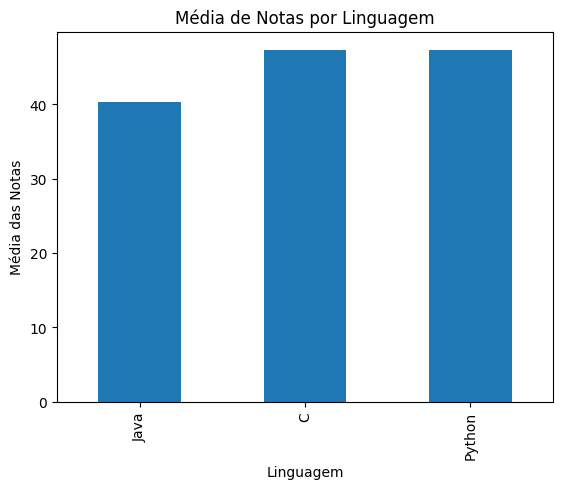

In [68]:
media_por_linguagem = df.groupby('linguagem')['nota'].mean().sort_values()
media_por_linguagem.plot(kind='bar')
plt.title('Média de Notas por Linguagem')
plt.xlabel('Linguagem')
plt.ylabel('Média das Notas')

Percebe-se que a linguagem java possui certa desvantagem em relação às demais, mas seria interessante também calcular a mediana, para adquirir uma confirmação com uma métrica mais consistente.

## Exercício 8
Descreva e analise algo relevante nos dados.

Text(0.5, 1.0, 'Mediana das Notas por Linguagem')

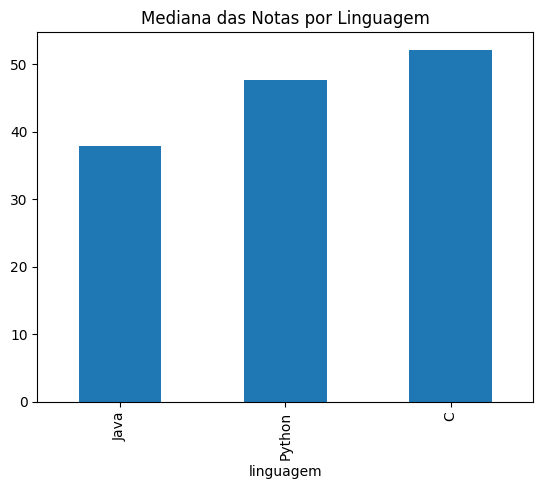

In [69]:
mediana_por_linguagem = df.groupby('linguagem')['nota'].median().sort_values()
mediana_por_linguagem.plot(kind='bar')
plt.title('Mediana das Notas por Linguagem')

A utilização da mediana confirma que os alunos que utilizaram linguagem Python, e principalmente C, obtiveram resultados melhores que os que utilizaram Java, com a mediana da Linguagem C estando acima de 50.

## Exercício 9
Descreva e analise algo relevante nos dados.

Text(0.5, 1.0, 'Mediana do tempo de Resolução por Linguagem')

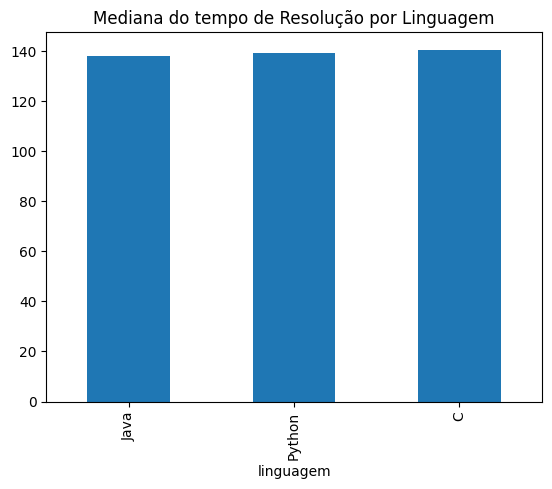

In [70]:
mediana_resolucao_por_linguagem = df.groupby('linguagem')['tempo_resolucao'].median().sort_values()
tempo_medio_resolucao_por_linguagem.plot(kind='bar')
plt.title('Mediana do tempo de Resolução por Linguagem')

Apesar de obterem resultados melhores em Python e C, não houve vantagem em questão de tempo de resolução quando comparando as linguagens utilizadas

## Exercício 10
Descreva e analise algo relevante nos dados.

Agora, veremos se o número de acessos à plataforma influencia nas notas, e se sim, positivamente ou negativamente

Text(0, 0.5, 'Média das Notas')

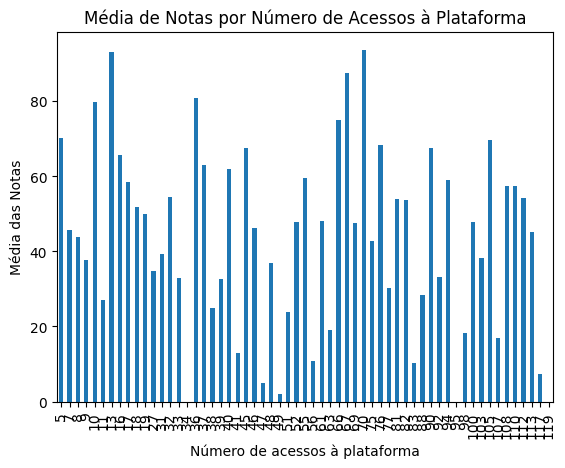

In [71]:
acessos_vs_nota = df.groupby('acessos_plataforma')['nota'].mean().sort_index()
acessos_vs_nota.plot(kind='bar')
plt.title('Média de Notas por Número de Acessos à Plataforma')
plt.xlabel('Número de acessos à plataforma')
plt.ylabel("Média das Notas")

A variabilidade da média das notas em relação ao número de acessos mostra que acessar muitas vezes a plataforma não garante bom desempenho.  
Por isso, deve-se instruir os alunos para utilizar a plataforma com intenção bem definida, focando na qualidade e objetivo dos acessos.

## Insights para melhorar o ensino: 
Recomendar que os alunos tenham preferência por utilizar Python ou C na disciplina, ou melhorar o ensino de java;  
Incentivar e criar metas de estudo semanal para os alunos;  
Monitorar a frequência e alertar alunos que possuem muitas faltas;  


## Exercício 11
Descreva e analise algo relevante nos dados.

In [72]:
# resposta aqui

## Exercício 12
Descreva e analise algo relevante nos dados.

In [73]:
# resposta aqui

## Exercício 13
Descreva e analise algo relevante nos dados.

In [74]:
# resposta aqui

## Exercício 14
Descreva e analise algo relevante nos dados.

In [75]:
# resposta aqui

## Exercício 15
Descreva e analise algo relevante nos dados.

In [76]:
# resposta aqui

## Exercício 16
Descreva e analise algo relevante nos dados.

In [77]:
# resposta aqui

## Exercício 17
Descreva e analise algo relevante nos dados.

In [78]:
# resposta aqui

## Exercício 18
Descreva e analise algo relevante nos dados.

In [79]:
# resposta aqui

## Exercício 19
Descreva e analise algo relevante nos dados.

In [80]:
# resposta aqui

## Exercício 20
Descreva e analise algo relevante nos dados.

In [81]:
# resposta aqui